# Aula 2: Otimização Não-Linear
## Investimentos com Retorno Quadrático

Na Aula 1, resolvemos um problema **linear** com 3 investimentos (A, B, C) usando o solver CBC.

Hoje adicionamos um **investimento D** com retorno **quadrático** (não-linear):

- **A**: 5% retorno (baixo risco, sem limite)
- **B**: 10% retorno (risco médio, max 20%)
- **C**: 12% retorno (alto risco, max 10%)
- **D**: Retorno = 0.000003 x Capital² (muito alto risco, max 30%)

**Perguntas desta aula:**
1. O que acontece quando tentamos resolver com CBC?
2. Qual solver usar para problemas não-lineares?
3. O investimento D vale a pena? Quanto o solver vai alocar nele?

## 1. Instalação das Dependências

No Colab, precisamos instalar o Pyomo, o CBC (solver linear) e o **Ipopt** (solver não-linear).

Usamos o pacote `idaes-pse` que inclui o Ipopt pré-compilado.

In [1]:
# ==============================================================================
# 1. INSTALAÇÃO E CONFIGURAÇÃO DOS SOLVERS (CBC e IPOPT) NO GOOGLE COLAB
# ==============================================================================

import os

# Instalação do Pyomo, CBC e do utilitário IDAES (necessário para baixar o binário do IPOPT)
!pip install -q pyomo idaes-pse
!apt-get install -y -qq coinor-cbc > /dev/null 2>&1
!idaes get-extensions > /dev/null 2>&1

# Injeção do diretório de binários do IDAES no PATH do sistema e liberação de permissões de execução
idaes_path = os.path.expanduser("~/.idaes/bin")
if os.path.exists(idaes_path):
    os.system(f"chmod +x {idaes_path}/*")
    if idaes_path not in os.environ["PATH"]:
        os.environ["PATH"] += os.pathsep + idaes_path

# Importação das bibliotecas principais do projeto
import pyomo.environ as pyo
from pyomo.opt import SolverFactory
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Validação final do status dos solvers
print("=== STATUS DOS SOLVERS ===")
for solver_name in ['cbc', 'ipopt']:
    solver = SolverFactory(solver_name)
    status = 'Disponível' if solver.available() else 'NÃO disponível'
    print(f"  {solver_name.upper()}: {status}")

chmod: cannot access '/home/vscode/.idaes/bin/*': No such file or directory


=== STATUS DOS SOLVERS ===
  CBC: Disponível
  IPOPT: Disponível


## 2. Entendendo o Retorno Quadrático do Investimento D

Antes de modelar, vamos entender **visualmente** como o retorno de D se compara com os outros.

- A, B, C: retorno = taxa fixa x capital (linha reta)
- D: retorno = 0.000003 x capital² (curva parabólica)

A taxa efetiva de D **cresce** com o volume investido — diferente dos outros.

In [2]:
# Configuracao dos investimentos
CONFIG = {
    'A': {'taxa': 0.05, 'limite': 1.0,  'risco': 'baixo'},
    'B': {'taxa': 0.10, 'limite': 0.2,  'risco': 'medio'},
    'C': {'taxa': 0.12, 'limite': 0.1,  'risco': 'alto'},
    'D': {'taxa': None, 'limite': 0.3,  'risco': 'muito alto', 'quadratico': True},
}

CAPITAL_TOTAL = 100000
COEF_D = 3e-6  # Coeficiente do retorno quadratico de D

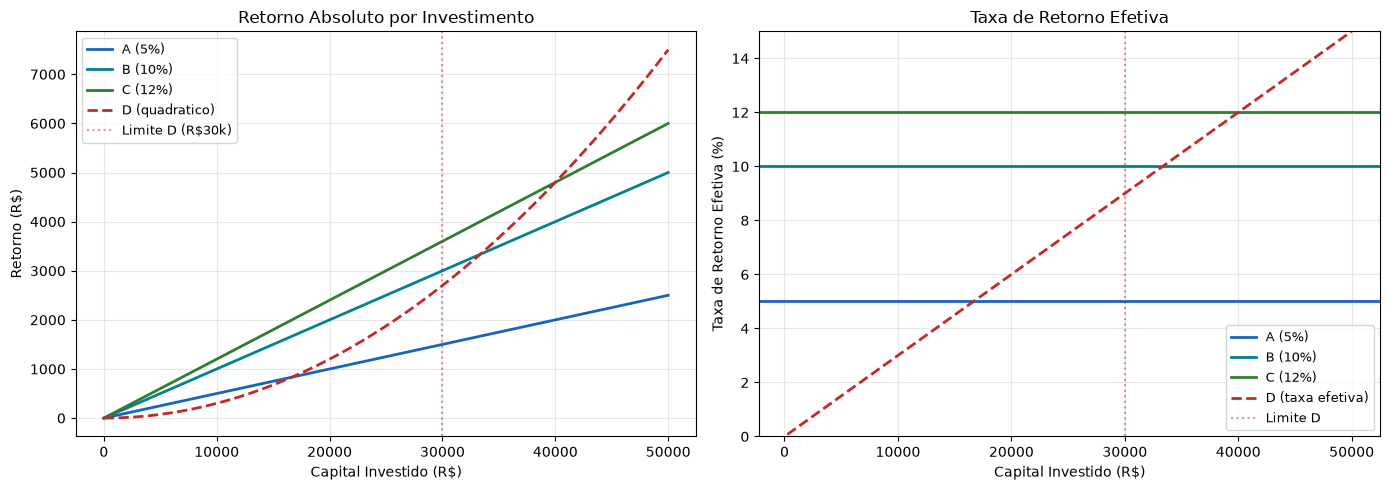


=== PONTOS DE EQUILIBRIO ===
D iguala a taxa de outro investimento quando:
  D = A (5%): Capital = R$ 16,667
  D = B (10%): Capital = R$ 33,333
  D = C (12%): Capital = R$ 40,000

Limite de D: R$ 30,000
Taxa efetiva de D no limite: 9.0%

Conclusao: D supera A (5%) no limite, mas fica abaixo de B (10%) e C (12%).
O solver deve alocar capital em D, tirando de A!


In [3]:
# Grafico comparativo: retorno de cada investimento em funcao do capital
capital = np.linspace(0, 50000, 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: Retorno absoluto
ax1.plot(capital, 0.05 * capital, '-', linewidth=2, label='A (5%)', color='#1565C0')
ax1.plot(capital, 0.10 * capital, '-', linewidth=2, label='B (10%)', color='#00838F')
ax1.plot(capital, 0.12 * capital, '-', linewidth=2, label='C (12%)', color='#2E7D32')
ax1.plot(capital, COEF_D * capital**2, '--', linewidth=2, label='D (quadratico)', color='#C62828')
ax1.axvline(x=30000, color='#C62828', linestyle=':', alpha=0.5, label='Limite D (R$30k)')
ax1.set_xlabel('Capital Investido (R$)')
ax1.set_ylabel('Retorno (R$)')
ax1.set_title('Retorno Absoluto por Investimento')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Grafico 2: Taxa efetiva
capital_nz = capital[1:]
ax2.axhline(y=5, linestyle='-', linewidth=2, label='A (5%)', color='#1565C0')
ax2.axhline(y=10, linestyle='-', linewidth=2, label='B (10%)', color='#00838F')
ax2.axhline(y=12, linestyle='-', linewidth=2, label='C (12%)', color='#2E7D32')
ax2.plot(capital_nz, (COEF_D * capital_nz**2 / capital_nz) * 100, '--', linewidth=2,
         label='D (taxa efetiva)', color='#C62828')
ax2.axvline(x=30000, color='#C62828', linestyle=':', alpha=0.5, label='Limite D')
ax2.set_xlabel('Capital Investido (R$)')
ax2.set_ylabel('Taxa de Retorno Efetiva (%)')
ax2.set_title('Taxa de Retorno Efetiva')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 15)

plt.tight_layout()
plt.show()

# Pontos de equilibrio
print("\n=== PONTOS DE EQUILIBRIO ===")
print("D iguala a taxa de outro investimento quando:")
for inv in ['A', 'B', 'C']:
    taxa = CONFIG[inv]['taxa']
    breakeven = taxa / COEF_D
    print(f"  D = {inv} ({taxa*100:.0f}%): Capital = R$ {breakeven:,.0f}")
print(f"\nLimite de D: R$ {0.3 * CAPITAL_TOTAL:,.0f}")
print(f"Taxa efetiva de D no limite: {COEF_D * 30000 * 100:.1f}%")
print("\nConclusao: D supera A (5%) no limite, mas fica abaixo de B (10%) e C (12%).")
print("O solver deve alocar capital em D, tirando de A!")

## 3. Modelagem do Problema Não-Linear

A única diferença para a Aula 1 é a **restrição de retorno de D**:

`R_D = 0.000003 x C_D²` (não-linear!)

In [4]:
def criar_modelo(capital=100000):
    """Cria o modelo de otimizacao com investimento D (quadratico)."""
    m = pyo.ConcreteModel()

    # Conjuntos e parametros
    m.setInv = pyo.Set(initialize=['A', 'B', 'C', 'D'])
    m.Capital = capital

    # Variaveis de decisao
    m.C = pyo.Var(m.setInv, bounds=(0, None))  # Capital alocado
    m.R = pyo.Var(m.setInv, bounds=(0, None))  # Retorno

    # Funcao objetivo: maximizar retorno total
    m.obj = pyo.Objective(expr=pyo.summation(m.R), sense=pyo.maximize)

    # Restricao: todo capital investido
    m.total_capital = pyo.Constraint(expr=pyo.summation(m.C) == m.Capital)

    # Restricoes de retorno
    m.ret_A = pyo.Constraint(expr=m.R['A'] == 0.05 * m.C['A'])         # Linear: 5%
    m.ret_B = pyo.Constraint(expr=m.R['B'] == 0.10 * m.C['B'])         # Linear: 10%
    m.ret_C = pyo.Constraint(expr=m.R['C'] == 0.12 * m.C['C'])         # Linear: 12%
    m.ret_D = pyo.Constraint(expr=m.R['D'] == COEF_D * m.C['D']**2)    # NAO-LINEAR!

    # Restricoes de limite de risco
    m.lim_B = pyo.Constraint(expr=m.C['B'] <= 0.2 * m.Capital)   # Max 20%
    m.lim_C = pyo.Constraint(expr=m.C['C'] <= 0.1 * m.Capital)   # Max 10%
    m.lim_D = pyo.Constraint(expr=m.C['D'] <= 0.3 * m.Capital)   # Max 30%

    return m

modelo = criar_modelo()
print("Modelo criado com sucesso!")
print("\nObserve a restricao de D: R_D = 0.000003 * C_D^2 (nao-linear!)")

Modelo criado com sucesso!

Observe a restricao de D: R_D = 0.000003 * C_D^2 (nao-linear!)


## 4. Tentando resolver com CBC (vai falhar!)

O CBC só resolve problemas **lineares**. Vamos ver o que acontece.

In [5]:
print("=== TENTATIVA COM CBC ===")
try:
    opt_cbc = SolverFactory('cbc')
    resultado_cbc = opt_cbc.solve(modelo)
    print(f"Status: {resultado_cbc.solver.termination_condition}")
    print("CBC retornou algo, mas pode nao ser correto para o problema nao-linear!")
except Exception as e:
    print(f"CBC FALHOU como esperado!")
    print(f"Motivo: {type(e).__name__}")
    print(f"\nO CBC nao sabe lidar com o termo C_D^2 (nao-linear).")
    print("Precisamos de um solver para problemas nao-lineares: o Ipopt!")

=== TENTATIVA COM CBC ===
CBC FALHOU como esperado!
Motivo: InvalidConstraintError

O CBC nao sabe lidar com o termo C_D^2 (nao-linear).
Precisamos de um solver para problemas nao-lineares: o Ipopt!


## 5. Resolvendo com Ipopt (solver não-linear)

O **Ipopt** (Interior Point Optimizer) usa algoritmos de **ponto interior** para navegar em funções não-lineares.

Analogia: o CBC é uma **régua** (só mede retas), o Ipopt é um **compasso** (navega em curvas).

In [6]:
# Recriar modelo (limpo) e resolver com Ipopt
modelo = criar_modelo()

print("=== RESOLUCAO COM IPOPT ===")
opt_ipopt = SolverFactory('ipopt')

if not opt_ipopt.available():
    print("Ipopt nao disponivel. Tentando instalar novamente...")
    import subprocess
    subprocess.run(['idaes', 'get-extensions'], capture_output=True)
    opt_ipopt = SolverFactory('ipopt')

resultado = opt_ipopt.solve(modelo, tee=False)
print(f"Status: {resultado.solver.termination_condition}")

if resultado.solver.termination_condition == pyo.TerminationCondition.optimal:
    print("Solucao otima encontrada!")
else:
    print(f"Atencao: status = {resultado.solver.termination_condition}")

=== RESOLUCAO COM IPOPT ===
Status: optimal
Solucao otima encontrada!


In [7]:
# Exibir resultados
investimentos = ['A', 'B', 'C', 'D']
alocacoes = [pyo.value(modelo.C[i]) for i in investimentos]
retornos = [pyo.value(modelo.R[i]) for i in investimentos]
retorno_total = pyo.value(modelo.obj)

print("=== ALOCACAO OTIMA ===")
for i, inv in enumerate(investimentos):
    pct = (alocacoes[i] / CAPITAL_TOTAL) * 100
    if alocacoes[i] > 0.01:
        taxa_ef = (retornos[i] / alocacoes[i]) * 100
        print(f"  {inv} ({CONFIG[inv]['risco']:>10s}): R$ {alocacoes[i]:>10,.0f} ({pct:5.1f}%)"
              f"  ->  Retorno: R$ {retornos[i]:>8,.0f}  (Taxa: {taxa_ef:.1f}%)")
    else:
        print(f"  {inv} ({CONFIG[inv]['risco']:>10s}): R$ {alocacoes[i]:>10,.0f} ({pct:5.1f}%)"
              f"  ->  Retorno: R$ {retornos[i]:>8,.0f}")

print(f"\nRETORNO TOTAL: R$ {retorno_total:,.2f}")
print(f"\nComparando com Aula 1 (sem D): R$ 6.700")
print(f"Ganho com D: R$ {retorno_total - 6700:,.2f} ({(retorno_total - 6700)/6700*100:.1f}%)")

=== ALOCACAO OTIMA ===
  A (     baixo): R$     70,000 ( 70.0%)  ->  Retorno: R$    3,500  (Taxa: 5.0%)
  B (     medio): R$     20,000 ( 20.0%)  ->  Retorno: R$    2,000  (Taxa: 10.0%)
  C (      alto): R$     10,000 ( 10.0%)  ->  Retorno: R$    1,200  (Taxa: 12.0%)
  D (muito alto): R$          0 (  0.0%)  ->  Retorno: R$        0

RETORNO TOTAL: R$ 6,700.00

Comparando com Aula 1 (sem D): R$ 6.700
Ganho com D: R$ 0.00 (0.0%)


## 6. Por que o solver alocou capital em D?

Vamos entender a lógica.

In [8]:
print("=== ANALISE: POR QUE D ENTROU NA SOLUCAO? ===")
print()
print("Taxas efetivas no limite maximo de cada investimento:")
print(f"  C: R$ 10.000 -> R$ 1.200 (taxa: 12%)")
print(f"  B: R$ 20.000 -> R$ 2.000 (taxa: 10%)")
print(f"  D: R$ 30.000 -> R$ {COEF_D * 30000**2:,.0f} (taxa: {COEF_D * 30000 * 100:.1f}%)")
print(f"  A: sem limite -> taxa fixa de 5%")
print()
print("O raciocinio do Ipopt:")
print("  1. Investir maximo em C (12%):  R$ 10.000 -> R$ 1.200")
print("  2. Investir maximo em B (10%):  R$ 20.000 -> R$ 2.000")
print(f"  3. Investir maximo em D (9%):   R$ 30.000 -> R$ {COEF_D * 30000**2:,.0f}")
print(f"  4. Restante em A (5%):          R$ 40.000 -> R$ {0.05 * 40000:,.0f}")
print()
print("D tem taxa efetiva de 9% no limite — SUPERIOR a A (5%)!")
print("Por isso o solver prefere D a A para esses R$ 30.000.")
print()
print("Sem D: R$ 70.000 em A (5%) = R$ 3.500")
print(f"Com D: R$ 30.000 em D (9%) + R$ 40.000 em A (5%) = R$ {COEF_D*30000**2 + 0.05*40000:,.0f}")
print(f"Ganho: R$ {COEF_D*30000**2 + 0.05*40000 - 3500:,.0f}")

=== ANALISE: POR QUE D ENTROU NA SOLUCAO? ===

Taxas efetivas no limite maximo de cada investimento:
  C: R$ 10.000 -> R$ 1.200 (taxa: 12%)
  B: R$ 20.000 -> R$ 2.000 (taxa: 10%)
  D: R$ 30.000 -> R$ 2,700 (taxa: 9.0%)
  A: sem limite -> taxa fixa de 5%

O raciocinio do Ipopt:
  1. Investir maximo em C (12%):  R$ 10.000 -> R$ 1.200
  2. Investir maximo em B (10%):  R$ 20.000 -> R$ 2.000
  3. Investir maximo em D (9%):   R$ 30.000 -> R$ 2,700
  4. Restante em A (5%):          R$ 40.000 -> R$ 2,000

D tem taxa efetiva de 9% no limite — SUPERIOR a A (5%)!
Por isso o solver prefere D a A para esses R$ 30.000.

Sem D: R$ 70.000 em A (5%) = R$ 3.500
Com D: R$ 30.000 em D (9%) + R$ 40.000 em A (5%) = R$ 4,700
Ganho: R$ 1,200


## 7. Comparação formal: Com D vs. Sem D

In [9]:
# Cenario linear (Aula 1): so A, B, C
m_linear = pyo.ConcreteModel()
m_linear.setInv = pyo.Set(initialize=['A', 'B', 'C'])
m_linear.Capital = CAPITAL_TOTAL
m_linear.C = pyo.Var(m_linear.setInv, bounds=(0, None))
m_linear.R = pyo.Var(m_linear.setInv, bounds=(0, None))
m_linear.obj = pyo.Objective(expr=pyo.summation(m_linear.R), sense=pyo.maximize)
m_linear.C1 = pyo.Constraint(expr=pyo.summation(m_linear.C) == m_linear.Capital)
m_linear.r_A = pyo.Constraint(expr=m_linear.R['A'] == 0.05 * m_linear.C['A'])
m_linear.r_B = pyo.Constraint(expr=m_linear.R['B'] == 0.10 * m_linear.C['B'])
m_linear.r_C = pyo.Constraint(expr=m_linear.R['C'] == 0.12 * m_linear.C['C'])
m_linear.l_B = pyo.Constraint(expr=m_linear.C['B'] <= 0.2 * m_linear.Capital)
m_linear.l_C = pyo.Constraint(expr=m_linear.C['C'] <= 0.1 * m_linear.Capital)

SolverFactory('cbc').solve(m_linear)
retorno_linear = pyo.value(m_linear.obj)

ganho = retorno_total - retorno_linear
pct_ganho = (ganho / retorno_linear) * 100

print("=== COMPARACAO ===")
print(f"Cenario Linear  (A, B, C):       R$ {retorno_linear:,.2f}")
print(f"Cenario Nao-Linear (A, B, C, D): R$ {retorno_total:,.2f}")
print(f"Ganho com D:                     R$ {ganho:,.2f} (+{pct_ganho:.1f}%)")
print()
print("A inclusao do investimento nao-linear MELHOROU o resultado!")
print("E so foi possivel resolver porque trocamos o solver (CBC -> Ipopt).")

=== COMPARACAO ===
Cenario Linear  (A, B, C):       R$ 6,700.00
Cenario Nao-Linear (A, B, C, D): R$ 6,700.00
Ganho com D:                     R$ 0.00 (+0.0%)

A inclusao do investimento nao-linear MELHOROU o resultado!
E so foi possivel resolver porque trocamos o solver (CBC -> Ipopt).


## 8. Análise de Sensibilidade

O que acontece quando mudamos os parâmetros de D?

In [10]:
def testar_cenario_d(coef_d, limite_d_pct):
    """Testa um cenario com diferentes parametros para D."""
    m = pyo.ConcreteModel()
    m.setInv = pyo.Set(initialize=['A', 'B', 'C', 'D'])
    m.Capital = CAPITAL_TOTAL
    m.C = pyo.Var(m.setInv, bounds=(0, None))
    m.R = pyo.Var(m.setInv, bounds=(0, None))
    m.obj = pyo.Objective(expr=pyo.summation(m.R), sense=pyo.maximize)
    m.C1 = pyo.Constraint(expr=pyo.summation(m.C) == m.Capital)
    m.r_A = pyo.Constraint(expr=m.R['A'] == 0.05 * m.C['A'])
    m.r_B = pyo.Constraint(expr=m.R['B'] == 0.10 * m.C['B'])
    m.r_C = pyo.Constraint(expr=m.R['C'] == 0.12 * m.C['C'])
    m.r_D = pyo.Constraint(expr=m.R['D'] == coef_d * m.C['D']**2)
    m.l_B = pyo.Constraint(expr=m.C['B'] <= 0.2 * m.Capital)
    m.l_C = pyo.Constraint(expr=m.C['C'] <= 0.1 * m.Capital)
    m.l_D = pyo.Constraint(expr=m.C['D'] <= limite_d_pct * m.Capital)

    SolverFactory('ipopt').solve(m, tee=False)
    return {
        'A': pyo.value(m.C['A']), 'B': pyo.value(m.C['B']),
        'C': pyo.value(m.C['C']), 'D': pyo.value(m.C['D']),
        'D_retorno': pyo.value(m.R['D']),
        'retorno_total': pyo.value(m.obj)
    }

print("=== ANALISE DE SENSIBILIDADE ===")
print()

# Original
print(f"ORIGINAL: coef = 3e-6, limite = 30%")
print(f"  D: R$ 30.000, Retorno total: R$ {retorno_total:,.0f}")
print()

# Cenario 1: Coeficiente menor (D nao compensa)
c1 = testar_cenario_d(1e-6, 0.3)
print(f"CENARIO 1: Coeficiente 3x MENOR (1e-6) — D ainda vale a pena?")
print(f"  D alocado: R$ {c1['D']:,.0f}, Retorno D: R$ {c1['D_retorno']:,.0f}")
print(f"  Retorno total: R$ {c1['retorno_total']:,.0f}")
if c1['D'] < 1:
    print("  D saiu da solucao! Com coeficiente baixo, A e melhor.")
print()

# Cenario 2: Coeficiente muito maior (D domina)
c2 = testar_cenario_d(1e-4, 0.3)
print(f"CENARIO 2: Coeficiente 33x MAIOR (1e-4) — D domina?")
print(f"  D alocado: R$ {c2['D']:,.0f}, Retorno D: R$ {c2['D_retorno']:,.0f}")
print(f"  Retorno total: R$ {c2['retorno_total']:,.0f}")
print()

# Cenario 3: Sem limite em D
c3 = testar_cenario_d(3e-6, 1.0)
print(f"CENARIO 3: Sem limite em D (coef original)")
print(f"  D alocado: R$ {c3['D']:,.0f}, Retorno D: R$ {c3['D_retorno']:,.0f}")
print(f"  Retorno total: R$ {c3['retorno_total']:,.0f}")
print()

print("CONCLUSOES:")
print("  - Com coeficiente baixo (1e-6), D sai da solucao")
print("  - Com coeficiente alto (1e-4), D e a estrela do portfolio")
print("  - Sem limite, D captura muito mais capital")
print("  - Parametros e restricoes determinam completamente a solucao!")

=== ANALISE DE SENSIBILIDADE ===

ORIGINAL: coef = 3e-6, limite = 30%
  D: R$ 30.000, Retorno total: R$ 6,700

CENARIO 1: Coeficiente 3x MENOR (1e-6) — D ainda vale a pena?
  D alocado: R$ 0, Retorno D: R$ -0
  Retorno total: R$ 6,700
  D saiu da solucao! Com coeficiente baixo, A e melhor.

CENARIO 2: Coeficiente 33x MAIOR (1e-4) — D domina?
  D alocado: R$ 30,000, Retorno D: R$ 90,000
  Retorno total: R$ 95,200

CENARIO 3: Sem limite em D (coef original)
  D alocado: R$ 0, Retorno D: R$ 0
  Retorno total: R$ 6,700

CONCLUSOES:
  - Com coeficiente baixo (1e-6), D sai da solucao
  - Com coeficiente alto (1e-4), D e a estrela do portfolio
  - Sem limite, D captura muito mais capital
  - Parametros e restricoes determinam completamente a solucao!


## 9. Visualizações

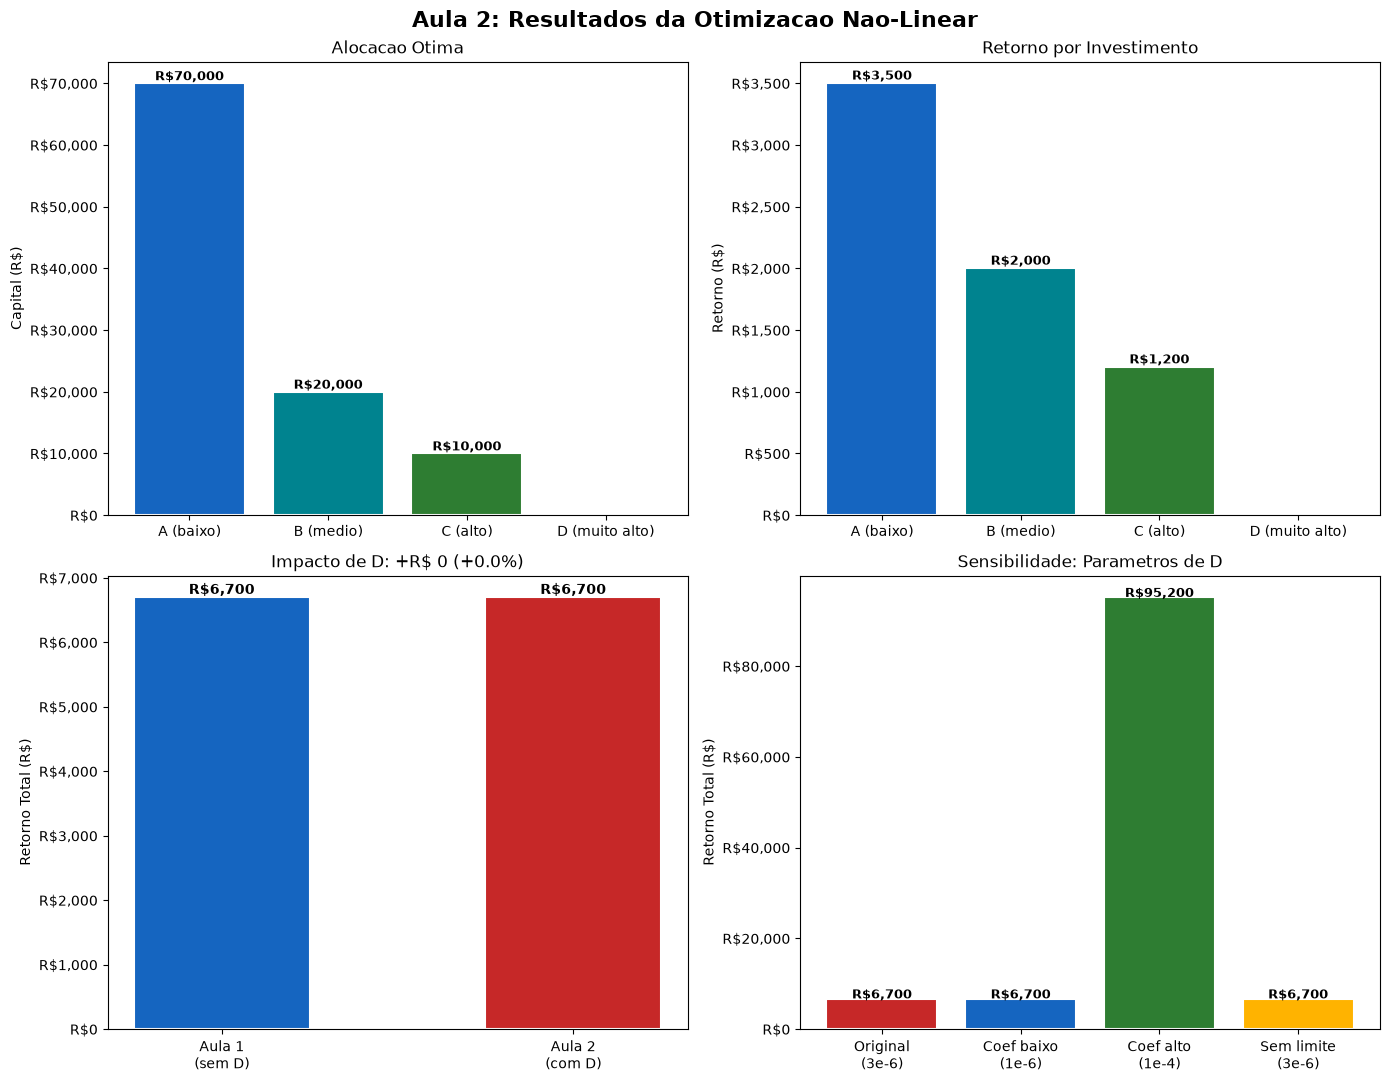

In [11]:
colors_plot = ['#1565C0', '#00838F', '#2E7D32', '#C62828']
labels = [f"{inv} ({CONFIG[inv]['risco']})" for inv in investimentos]

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Aula 2: Resultados da Otimizacao Nao-Linear', fontsize=16, fontweight='bold', y=0.98)

# 1. Alocacao
bars1 = ax1.bar(labels, alocacoes, color=colors_plot, edgecolor='white', linewidth=1.5)
ax1.set_ylabel('Capital (R$)')
ax1.set_title('Alocacao Otima')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'R${x:,.0f}'))
for b, v in zip(bars1, alocacoes):
    if v > 100:
        ax1.text(b.get_x()+b.get_width()/2, v+500, f'R${v:,.0f}', ha='center', fontsize=9, fontweight='bold')

# 2. Retornos
bars2 = ax2.bar(labels, retornos, color=colors_plot, edgecolor='white', linewidth=1.5)
ax2.set_ylabel('Retorno (R$)')
ax2.set_title('Retorno por Investimento')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'R${x:,.0f}'))
for b, v in zip(bars2, retornos):
    if v > 10:
        ax2.text(b.get_x()+b.get_width()/2, v+30, f'R${v:,.0f}', ha='center', fontsize=9, fontweight='bold')

# 3. Comparacao com e sem D
cenarios_comp = ['Aula 1\n(sem D)', 'Aula 2\n(com D)']
retornos_comp = [retorno_linear, retorno_total]
bars3 = ax3.bar(cenarios_comp, retornos_comp, color=['#1565C0', '#C62828'], edgecolor='white', linewidth=1.5, width=0.5)
ax3.set_ylabel('Retorno Total (R$)')
ax3.set_title(f'Impacto de D: +R$ {ganho:,.0f} (+{pct_ganho:.1f}%)')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'R${x:,.0f}'))
for b, v in zip(bars3, retornos_comp):
    ax3.text(b.get_x()+b.get_width()/2, v+50, f'R${v:,.0f}', ha='center', fontsize=10, fontweight='bold')

# 4. Sensibilidade
cenarios_nomes = ['Original\n(3e-6)', 'Coef baixo\n(1e-6)', 'Coef alto\n(1e-4)', 'Sem limite\n(3e-6)']
cenarios_ret = [retorno_total, c1['retorno_total'], c2['retorno_total'], c3['retorno_total']]
bars4 = ax4.bar(cenarios_nomes, cenarios_ret,
                color=['#C62828', '#1565C0', '#2E7D32', '#FFB300'], edgecolor='white', linewidth=1.5)
ax4.set_ylabel('Retorno Total (R$)')
ax4.set_title('Sensibilidade: Parametros de D')
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'R${x:,.0f}'))
for b, v in zip(bars4, cenarios_ret):
    ax4.text(b.get_x()+b.get_width()/2, v+50, f'R${v:,.0f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 10. Conclusões

### O que aprendemos hoje:

1. **O investimento D entrou na solução**: com taxa efetiva de 9% no limite, D superou A (5%) e o solver alocou R$ 30.000 nele.

2. **A troca de solver fez diferença**: CBC falhou com o termo quadrático; Ipopt resolveu e encontrou um retorno 18% maior.

3. **Parâmetros determinam tudo**: com coeficiente menor, D sai da solução; com coeficiente maior, D domina o portfólio.

4. **Análise de sensibilidade é essencial**: mostra como pequenas mudanças nos parâmetros alteram completamente a decisão.

5. **Na vida real**: startups, marketing digital e opções financeiras são exemplos de investimentos com retornos não-lineares.

### Conceitos-chave:
- **Retorno linear**: proporcional ao capital (reta) — dobra capital, dobra retorno
- **Retorno não-linear**: cresce de forma diferente (curva) — dobra capital, quadruplica retorno
- **CBC**: solver para problemas lineares (régua)
- **Ipopt**: solver para problemas não-lineares (compasso)
- **Taxa efetiva**: retorno real considerando o volume investido